In [1]:
# Importing the necessary packages 

import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

In [2]:
# Download latest version
path = kagglehub.dataset_download("vesnab/original-2017-nyc-yellow-taxi-data-raw-version")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\vesnab\original-2017-nyc-yellow-taxi-data-raw-version\versions\1


In [3]:
file_path = r'C:\Users\USER\.cache\kagglehub\datasets\vesnab\original-2017-nyc-yellow-taxi-data-raw-version\versions\1\2017_Yellow_Taxi_Trip_Data.csv'
df = pd.read_csv(file_path)

df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


In [5]:
df.to_csv('original-2017-nyc-yellow-taxi-data.csv', index=False)

In [6]:
# Checking the number of rows and columns
df.shape

(22699, 18)

In [7]:
# Checking the dataframe information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

In [8]:
# Convert pickup and dropoff strings to datetime
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

In [9]:
# Feature extraction: duration in minutes and temporal features
df["duration_minutes"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60.0
df["hour_of_day"] = df["tpep_pickup_datetime"].dt.hour
df["day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek
df["month"] = df["tpep_pickup_datetime"].dt.month

In [10]:
# Clean invalid values and outliers
clean_mask = (
    (df["fare_amount"] > 0)
    & (df["trip_distance"] > 0)
    & (df["duration_minutes"] > 1)
    & (df["duration_minutes"] < 1440)
    & (df["passenger_count"] > 0)
)
df_clean = df[clean_mask].copy()

In [11]:
# Drop unnecessary identifier columns
df_clean = df_clean.drop(
    columns=["Unnamed: 0", "tpep_pickup_datetime", "tpep_dropoff_datetime"],
    errors="ignore",
)

In [12]:
df_clean.head()

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration_minutes,hour_of_day,day_of_week,month
0,2,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56,14.066667,8,5,3
1,1,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80,26.500000,14,1,4
2,1,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75,7.200000,7,4,12
3,2,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69,30.250000,13,6,5
4,2,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80,16.716667,23,5,4


##  FEATURE ENGINEERING & SELECTION

In [13]:
# Target variable: fare_amount (exclude other financial fields to prevent data leakage)
y = df_clean["fare_amount"]

In [14]:
# Categorical and numerical predictor definitions
cat_cols = ["RatecodeID", "PULocationID", "DOLocationID"]
num_cols = [
    "trip_distance",
    "duration_minutes",
    "passenger_count",
    "hour_of_day",
    "day_of_week",
    "month",
]

In [15]:
# One-Hot Encoding for categorical features
X_encoded = pd.get_dummies(
    df_clean[num_cols + cat_cols], 
    columns=cat_cols, drop_first=True
)

In [16]:
# Train / Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, random_state=42, test_size=0.2
)

In [17]:
# Scale numeric features for Linear Regression
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

## MODEL 1: LINEAR REGRESSION (BASELINE)

In [18]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("=== Linear Regression Performance ===")
print(f"MAE:  ${mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred_lr):.4f}\n")

=== Linear Regression Performance ===
MAE:  $1.83
RMSE: $3.08
R²:   0.9208



## MODEL 2: RANDOM FOREST REGRESSOR

In [19]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("==> Random Forest Performance <==")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"MAE:  ${mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred_rf):.4f}")

==> Random Forest Performance <==
Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
MAE:  $0.38
RMSE: $1.50
R²:   0.9813


In [20]:
# Extract feature importances from the fitted Random Forest model
importances = best_rf.feature_importances_
feature_names = X_train.columns

In [24]:
# Build DataFrame and sort features
feat_imp = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values(by="Importance", ascending=False).head(10)
)

# View top 10 features
feat_imp.head(10)

,Feature,Importance
0,trip_distance,0.786879
1,duration_minutes,0.175458
6,RatecodeID_2,0.012749
9,RatecodeID_5,0.011817
7,RatecodeID_3,0.003504
369,DOLocationID_265,0.002854
3,hour_of_day,0.000956
5,month,0.000677
4,day_of_week,0.000583
154,PULocationID_265,0.000490


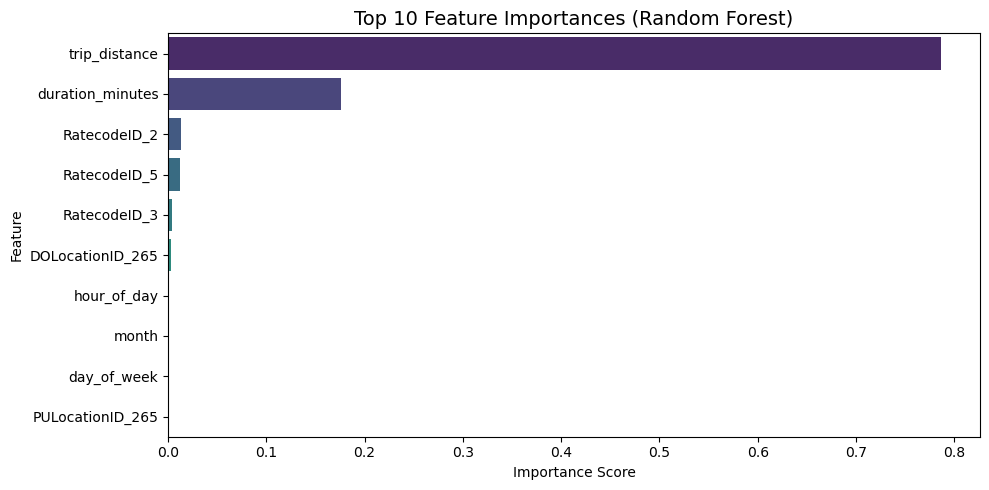

In [25]:
# Plot top features
plt.figure(figsize=(10, 5))
sns.barplot(data=feat_imp, x="Importance", y="Feature", 
            palette="viridis",legend=False,hue="Feature")
plt.title("Top 10 Feature Importances (Random Forest)", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
# Save the figure (dpi=300 ensures high resolution for reports/presentations)
plt.savefig("Top 10 Feature Importances (Random Forest).png", 
            dpi=300, bbox_inches="tight")

plt.show()

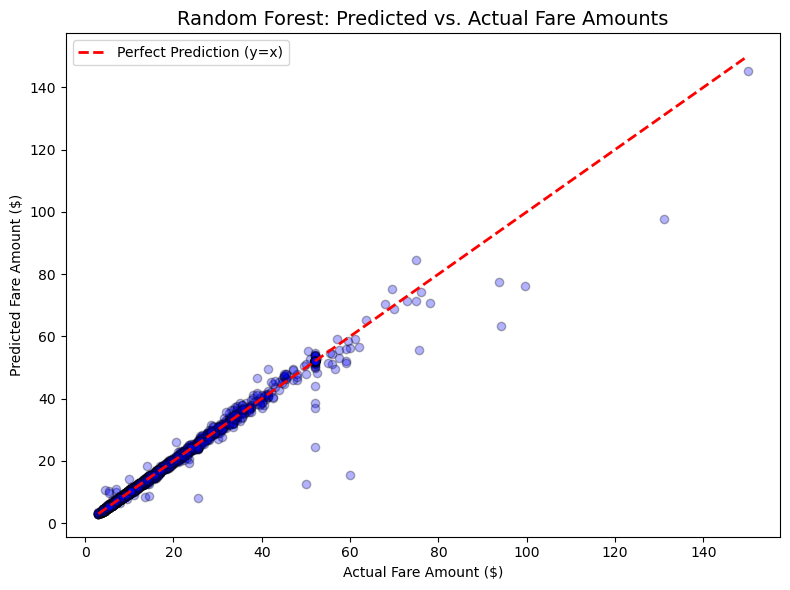

In [26]:
# Plot Predicted vs. Actual values to inspect model residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color="blue", edgecolors="k")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Perfect Prediction (y=x)",
)

plt.title("Random Forest: Predicted vs. Actual Fare Amounts", fontsize=14)
plt.xlabel("Actual Fare Amount ($)")
plt.ylabel("Predicted Fare Amount ($)")
plt.legend()
plt.tight_layout()
# Save the figure (dpi=300 ensures high resolution for reports/presentations)
plt.savefig("Random Forest: Predicted vs. Actual Fare Amounts.png", 
            dpi=300, bbox_inches="tight")

plt.show()

## TEST PREDICTION FUNCTION (DEMO)

In [27]:
# Save the best Random Forest model
joblib.dump(best_rf, "nyc_taxi_rf_model.pkl")

['nyc_taxi_rf_model.pkl']

In [28]:
# Save the model and scaler to disk
joblib.dump(best_rf, "nyc_taxi_rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Model and Scaler successfully saved to disk!\n")

Model and Scaler successfully saved to disk!



In [29]:
# Simplified test prediction function for Random Forest
def predict_fare_rf(model, sample_df_row):
    """Predicts fare using unscaled sample features for Random Forest."""
    return model.predict(sample_df_row)[0]

# Pick a sample row from X_test
sample_index = X_test.index[0]
sample_features = X_test.loc[[sample_index]]
actual_fare = y_test.loc[sample_index]

predicted_fare = predict_fare_rf(best_rf, sample_features)

print(f"Actual Fare:    ${actual_fare:.2f}")
print(f"Predicted Fare: ${predicted_fare:.2f}")

Actual Fare:    $10.00
Predicted Fare: $10.10
